## PC filter — hardware validation across the test set

Loads PC filter weights (thresholds + LUT) onto the FPGA, runs every pre-LR frame in the sequence through hardware, and reports PSNR gain vs. the unfiltered input, plus targeted correctness checks (constant-image test, threshold/LUT sanity checks, RU-level gain analysis).

In [1]:
from pynq import Overlay
import numpy as np
import os, glob, time

BASE   = '/home/xilinx/jupyter_notebooks/pc_filter'
SEQ    = f'{BASE}/TreesAndGrass_1920_1080_30fps_8bit'
HR_DIR = f'{SEQ}/TEST_HR'
LR_DIR = f'{SEQ}/TEST_PRELR/RANGE_1'
W, H   = 1920, 1080

ol     = Overlay(f'{BASE}/pc_filter_bd_wrapper.bit')
dma    = ol.axi_dma_0
pc_flt = ol.pc_filter_0

# Fix for PYNQ start() hang — DMA is already running after overlay load
dma.sendchannel._first_transfer = True
dma.recvchannel._first_transfer = True
print("Overlay loaded. DMA ready.")

Overlay loaded. DMA ready.


In [2]:
import numpy as np

data        = np.load(f'{BASE}/pc_qp_group_1.npz')
T_float     = data['T']
LUT         = data['LUT']
cluster_map = data['cluster_map']
LUT_fixed   = np.round(LUT * 8192).astype(np.int32)

# Derive Q2.14 thresholds from the model — never hardcode
T_Q2_14 = np.round(T_float * 16384).astype(int).tolist()
for i, t in enumerate(T_Q2_14):
    pc_flt.write(i * 4, int(t))

pc_flt.write(0x1C, (int(H) << 16) | int(W))

print("Thresholds:", [pc_flt.read(i*4) for i in range(7)])
rb = pc_flt.read(0x1C)
print(f"Dims: W={rb & 0x7FF}, H={(rb>>16) & 0x7FF}")

Thresholds: [0, 5, 10, 26, 57, 123, 280]
Dims: W=1920, H=1080


In [3]:
from pynq import allocate

N_in  = H * W
N_out = (H - 6) * (W - 6)
input_buf  = allocate(shape=(N_in,),  dtype=np.uint32)
output_buf = allocate(shape=(N_out,), dtype=np.uint32)

def load_raw_y(path):
    with open(path, 'rb') as f:
        return np.frombuffer(f.read(W * H), dtype=np.uint8).reshape(H, W).copy()

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

def run_fpga(img_np):
    input_buf[:] = img_np.flatten().astype(np.uint32)
    dma.recvchannel.transfer(output_buf)
    dma.sendchannel.transfer(input_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    interior = (output_buf & 0xFF).astype(np.uint8).reshape(H-6, W-6)
    result = img_np.copy()
    result[3:H-3, 3:W-3] = interior
    return result

print(f"Buffers allocated. Input: {N_in} words, Output: {N_out} words")

Buffers allocated. Input: 2073600 words, Output: 2055636 words


In [4]:
results = []  # (frame_id, qp, psnr_before, psnr_after, gain)

prelr_files = sorted(glob.glob(f'{LR_DIR}/*.yuv'))
print(f"Found {len(prelr_files)} pre-LR files\n")

for prelr_path in prelr_files:
    fname   = os.path.basename(prelr_path)               # frame_021_qp170_prelr.yuv
    parts   = fname.replace('_prelr.yuv','').split('_')  # ['frame','021','qp170']
    frame_id = parts[1]
    qp       = parts[2].replace('qp','')

    hr_path = f'{HR_DIR}/frame_{frame_id}.y'
    if not os.path.exists(hr_path):
        print(f"  Skipping {fname} — no HR reference")
        continue

    prelr = load_raw_y(prelr_path)
    hr    = load_raw_y(hr_path)

    t0       = time.time()
    filtered = run_fpga(prelr)
    elapsed  = (time.time() - t0) * 1000

    # Compare interior only (border pixels are copied from prelr)
    pb = psnr(prelr[3:-3, 3:-3], hr[3:-3, 3:-3])
    pa = psnr(filtered[3:-3, 3:-3], hr[3:-3, 3:-3])
    gain = pa - pb

    results.append((frame_id, qp, pb, pa, gain))
    print(f"frame_{frame_id} qp={qp}  before={pb:.3f} dB  after={pa:.3f} dB  gain={gain:+.3f} dB  ({elapsed:.0f}ms)")

print(f"\nDone. {len(results)} frames processed.")

Found 90 pre-LR files

frame_013 qp=160  before=26.815 dB  after=26.834 dB  gain=+0.019 dB  (329ms)
frame_013 qp=170  before=24.988 dB  after=25.017 dB  gain=+0.029 dB  (323ms)
frame_013 qp=180  before=23.288 dB  after=23.305 dB  gain=+0.017 dB  (323ms)
frame_014 qp=160  before=26.852 dB  after=26.864 dB  gain=+0.013 dB  (322ms)
frame_014 qp=170  before=25.030 dB  after=25.058 dB  gain=+0.027 dB  (322ms)
frame_014 qp=180  before=23.332 dB  after=23.344 dB  gain=+0.012 dB  (322ms)
frame_021 qp=160  before=27.069 dB  after=27.108 dB  gain=+0.039 dB  (322ms)
frame_021 qp=170  before=25.276 dB  after=25.313 dB  gain=+0.037 dB  (323ms)
frame_021 qp=180  before=23.606 dB  after=23.622 dB  gain=+0.016 dB  (324ms)
frame_023 qp=160  before=27.342 dB  after=27.345 dB  gain=+0.002 dB  (322ms)
frame_023 qp=170  before=25.567 dB  after=25.576 dB  gain=+0.009 dB  (322ms)
frame_023 qp=180  before=23.926 dB  after=23.928 dB  gain=+0.001 dB  (323ms)
frame_024 qp=160  before=27.249 dB  after=27.266 dB  

In [5]:
import numpy as np

gains  = [r[4] for r in results]
before = [r[2] for r in results]
after  = [r[3] for r in results]

print("=" * 55)
print(f"Frames processed     : {len(results)}")
print(f"Avg PSNR before      : {np.mean(before):.3f} dB")
print(f"Avg PSNR after       : {np.mean(after):.3f} dB")
print(f"Avg gain             : {np.mean(gains):+.3f} dB")
print(f"Max gain             : {np.max(gains):+.3f} dB")
print(f"Min gain             : {np.min(gains):+.3f} dB")
print(f"Frames improved      : {sum(g>0 for g in gains)}/{len(gains)}")
print("=" * 55)

# Per-QP breakdown
for qp in ['160', '170', '180']:
    subset = [r for r in results if r[1] == qp]
    if subset:
        g = [r[4] for r in subset]
        print(f"QP {qp}: avg gain = {np.mean(g):+.3f} dB  ({len(g)} frames)")

Frames processed     : 90
Avg PSNR before      : 25.768 dB
Avg PSNR after       : 25.773 dB
Avg gain             : +0.005 dB
Max gain             : +0.039 dB
Min gain             : -0.045 dB
Frames improved      : 62/90
QP 160: avg gain = +0.000 dB  (30 frames)
QP 170: avg gain = +0.012 dB  (30 frames)
QP 180: avg gain = +0.005 dB  (30 frames)


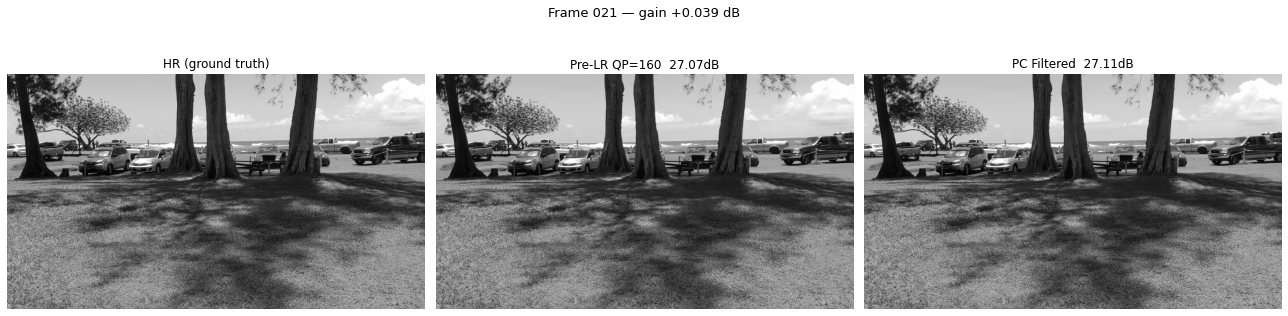

In [6]:
import matplotlib.pyplot as plt

# Pick the frame with the best PSNR gain
best = max(results, key=lambda r: r[4])
frame_id, qp = best[0], best[1]

prelr    = load_raw_y(f'{LR_DIR}/frame_{frame_id}_qp{qp}_prelr.yuv')
hr       = load_raw_y(f'{HR_DIR}/frame_{frame_id}.y')
filtered = run_fpga(prelr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(hr,       cmap='gray', vmin=0, vmax=255); axes[0].set_title('HR (ground truth)');   axes[0].axis('off')
axes[1].imshow(prelr,    cmap='gray', vmin=0, vmax=255); axes[1].set_title(f'Pre-LR QP={qp}  {best[2]:.2f}dB'); axes[1].axis('off')
axes[2].imshow(filtered, cmap='gray', vmin=0, vmax=255); axes[2].set_title(f'PC Filtered  {best[3]:.2f}dB'); axes[2].axis('off')
plt.suptitle(f'Frame {frame_id} — gain {best[4]:+.3f} dB', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# 1. Verify thresholds match the model
print("T_float from npz     :", T_float)
print("T_float × 16384      :", np.round(T_float * 16384).astype(int))
print("What we wrote to FPGA:", T_Q2_14)
print()

# 2. Golden model on a real patch from actual data
prelr = load_raw_y(f'{LR_DIR}/frame_021_qp170_prelr.yuv')

def golden(patch):
    p_f = patch.astype(np.float32) / 255.0
    p_i = patch.astype(np.int32).flatten()
    def mal(dr, dc):
        return sum(abs(-p_f[r+dr[0], c+dc[0]] + 2*p_f[r,c] - p_f[r+dr[1], c+dc[1]])
                   for r in range(1,6) for c in range(1,6)) / 25.0
    feats = [mal([0,0],[-1,1]), mal([-1,1],[0,0]), mal([-1,1],[-1,1]), mal([-1,1],[1,-1])]
    q   = [int((f >= T_float).sum()) for f in feats]
    ctx = q[0] + 8*q[1] + 64*q[2] + 512*q[3]
    fid = int(cluster_map[ctx])
    s   = int(np.dot(LUT_fixed[fid], p_i))
    return int(np.clip(s >> 13, 0, 255)), ctx, fid

# Compare golden vs FPGA on 10 scattered pixels
filtered = run_fpga(prelr)
print("row  col | center | golden | FPGA | ctx  fid")
print("-" * 48)
for r, c in [(3,3), (100,200), (300,500), (500,800), (700,1000),
             (200,300), (400,600), (600,900), (800,1200), (1000,1500)]:
    patch = prelr[r-3:r+4, c-3:c+4]
    g, ctx, fid = golden(patch)
    print(f"{r:4d} {c:4d} | {prelr[r,c]:6d} | {g:6d} | {filtered[r,c]:4d} | {ctx:4d} {fid:3d}")

T_float from npz     : [1.1920929e-09 3.1372547e-04 6.2745158e-04 1.5686273e-03 3.4509802e-03
 7.5294119e-03 1.7098036e-02]
T_float × 16384      : [  0   5  10  26  57 123 280]
What we wrote to FPGA: [0, 5, 10, 26, 57, 123, 280]

row  col | center | golden | FPGA | ctx  fid
------------------------------------------------
   3    3 |    111 |    111 |  111 | 4087  25
 100  200 |     60 |     56 |   57 | 4095 138
 300  500 |    188 |    193 |  194 | 4095 138
 500  800 |     40 |     39 |   40 | 2332 143
 700 1000 |    136 |    134 |  135 | 4095 138
 200  300 |     24 |     23 |   23 | 4095 138
 400  600 |    255 |    255 |  255 | 2988 224
 600  900 |     97 |     99 |  100 | 4095 138
 800 1200 |     35 |     34 |   35 | 4094 138
1000 1500 |    136 |    131 |  132 | 4095 138


In [8]:
prelr    = load_raw_y(f'{LR_DIR}/frame_021_qp170_prelr.yuv')
hr       = load_raw_y(f'{HR_DIR}/frame_021.y')
filtered = run_fpga(prelr)

R0, C0, N = 400, 600, 60

gold = np.zeros((N, N), dtype=np.uint8)
for i in range(N):
    for j in range(N):
        r, c = R0+i, C0+j
        gold[i, j] = golden(prelr[r-3:r+4, c-3:c+4])[0]

fpga_reg  = filtered[R0:R0+N, C0:C0+N]
prelr_reg = prelr[R0:R0+N, C0:C0+N]
hr_reg    = hr[R0:R0+N, C0:C0+N]

print("Q1 — is the RTL faithful to the model?")
print(f"  MAE golden vs FPGA : {np.mean(np.abs(gold.astype(int)-fpga_reg.astype(int))):.2f}")
print(f"  exact matches      : {np.mean(gold==fpga_reg)*100:.1f}%")
print()
print("Q2 — does the model itself help?")
print(f"  PSNR prelr  vs HR : {psnr(prelr_reg, hr_reg):.3f} dB")
print(f"  PSNR golden vs HR : {psnr(gold,      hr_reg):.3f} dB")
print(f"  PSNR FPGA   vs HR : {psnr(fpga_reg,  hr_reg):.3f} dB")

Q1 — is the RTL faithful to the model?
  MAE golden vs FPGA : 0.48
  exact matches      : 52.4%

Q2 — does the model itself help?
  PSNR prelr  vs HR : 27.614 dB
  PSNR golden vs HR : 27.557 dB
  PSNR FPGA   vs HR : 27.571 dB


In [9]:
prelr    = load_raw_y(f'{LR_DIR}/frame_021_qp170_prelr.yuv')
filtered = run_fpga(prelr)

R0, C0, N = 400, 600, 40

gold = np.zeros((N, N), dtype=np.uint8)
for i in range(N):
    for j in range(N):
        r, c = R0+i, C0+j
        gold[i, j] = golden(prelr[r-3:r+4, c-3:c+4])[0]

results_shift = []
for dr in range(-8, 9):
    for dc in range(-8, 9):
        fp  = filtered[R0+dr:R0+dr+N, C0+dc:C0+dc+N]
        mae = np.mean(np.abs(fp.astype(int) - gold.astype(int)))
        results_shift.append((mae, dr, dc))

results_shift.sort()
print("Best 8 shifts (MAE, dr, dc):")
for mae, dr, dc in results_shift[:8]:
    print(f"  MAE={mae:6.2f}   shift=({dr:+d},{dc:+d})")
print(f"\nMAE at (0,0): {[m for m,r,c in results_shift if r==0 and c==0][0]:.2f}")

Best 8 shifts (MAE, dr, dc):
  MAE=  0.48   shift=(+0,+0)
  MAE=  4.07   shift=(+0,+1)
  MAE=  4.14   shift=(+0,-1)
  MAE=  7.34   shift=(+0,-2)
  MAE=  7.40   shift=(+0,+2)
  MAE=  9.73   shift=(+0,-3)
  MAE=  9.93   shift=(+0,+3)
  MAE= 11.51   shift=(+0,-4)

MAE at (0,0): 0.48


In [10]:
# TEST 1 — constant image. Every patch identical → output must be constant.
const = np.full((H, W), 128, dtype=np.uint8)
out   = run_fpga(const)
inner = out[3:-3, 3:-3]
g     = golden(const[0:7, 0:7])[0]

print("TEST 1 — constant image (128)")
print(f"  golden           : {g}")
print(f"  FPGA unique vals : {np.unique(inner)[:10]}")
print(f"  FPGA min/max     : {inner.min()} / {inner.max()}")
print()

# TEST 2 — horizontal ramp. Column-dependent output exposes any column shift.
ramp = np.tile((np.arange(W) % 256).astype(np.uint8), (H, 1))
out2 = run_fpga(ramp)

print("TEST 2 — horizontal ramp")
print("  col | input | golden | FPGA")
for c in [100, 101, 102, 103, 104, 105]:
    gv = golden(ramp[100-3:100+4, c-3:c+4])[0]
    print(f"  {c:4d} | {ramp[100,c]:5d} | {gv:6d} | {out2[100,c]:4d}")

# TEST 3 — vertical ramp. Exposes row shifts / line-buffer row indexing.
vramp = np.tile((np.arange(H) % 256).astype(np.uint8).reshape(-1,1), (1, W))
out3  = run_fpga(vramp)

print("\nTEST 3 — vertical ramp")
print("  row | input | golden | FPGA")
for r in [100, 101, 102, 103, 104, 105]:
    gv = golden(vramp[r-3:r+4, 100-3:100+4])[0]
    print(f"  {r:4d} | {vramp[r,100]:5d} | {gv:6d} | {out3[r,100]:4d}")

TEST 1 — constant image (128)
  golden           : 128
  FPGA unique vals : [128]
  FPGA min/max     : 128 / 128

TEST 2 — horizontal ramp
  col | input | golden | FPGA
   100 |   100 |    100 |  100
   101 |   101 |    101 |  101
   102 |   102 |    102 |  102
   103 |   103 |    103 |  103
   104 |   104 |    104 |  104
   105 |   105 |    105 |  105

TEST 3 — vertical ramp
  row | input | golden | FPGA
   100 |   100 |    100 |  100
   101 |   101 |    101 |  101
   102 |   102 |    102 |  102
   103 |   103 |    103 |  103
   104 |   104 |    104 |  104
   105 |   105 |    105 |  105


In [11]:
sym = [np.allclose(LUT[f], LUT[f][::-1]) for f in range(256)]
print(f"Origin-symmetric filters: {sum(sym)}/256")
print("Example fid=138:", np.allclose(LUT[138], LUT[138][::-1]))

Origin-symmetric filters: 256/256
Example fid=138: True


In [12]:
R0, C0, N = 400, 600, 60

for rng in ['RANGE_0','RANGE_1','RANGE_2','RANGE_3','RANGE_4']:
    files = sorted(glob.glob(f'{SEQ}/TEST_PRELR/{rng}/*.yuv'))
    if not files: 
        continue
    f0  = files[0]
    fid_ = os.path.basename(f0).split('_')[1]
    pre = load_raw_y(f0)
    hr_ = load_raw_y(f'{HR_DIR}/frame_{fid_}.y')
    g = np.zeros((N,N), dtype=np.uint8)
    for i in range(N):
        for j in range(N):
            g[i,j] = golden(pre[R0+i-3:R0+i+4, C0+j-3:C0+j+4])[0]
    pb = psnr(pre[R0:R0+N, C0:C0+N], hr_[R0:R0+N, C0:C0+N])
    pa = psnr(g, hr_[R0:R0+N, C0:C0+N])
    print(f"{rng}  {os.path.basename(f0)[:22]}  before={pb:.3f}  golden={pa:.3f}  gain={pa-pb:+.3f} dB")

RANGE_1  frame_013_qp160_prelr.  before=28.152  golden=28.189  gain=+0.037 dB


In [13]:
RU = 256   # try 64, 128, 256

def ru_analysis(prelr, filtered, hr, ru=RU):
    h, w = hr.shape
    gains, wins = [], []
    for i in range(3, h-3-ru, ru):
        for j in range(3, w-3-ru, ru):
            p = prelr[i:i+ru, j:j+ru].astype(np.float64)
            f = filtered[i:i+ru, j:j+ru].astype(np.float64)
            t = hr[i:i+ru, j:j+ru].astype(np.float64)
            mse_p, mse_f = np.mean((p-t)**2), np.mean((f-t)**2)
            if mse_p > 0 and mse_f > 0:
                g = 10*np.log10(mse_p/mse_f)     # +ve = filter helps
                gains.append(g)
                wins.append(max(g, 0.0))          # RDO: fall back if it hurts
    return np.array(gains), np.array(wins)

all_g, all_w = [], []
for qp in ['160','170','180']:
    for fp in sorted(glob.glob(f'{LR_DIR}/*_qp{qp}_prelr.yuv'))[:10]:
        fid_ = os.path.basename(fp).split('_')[1]
        pre  = load_raw_y(fp)
        hr_  = load_raw_y(f'{HR_DIR}/frame_{fid_}.y')
        filt = run_fpga(pre)
        g, w = ru_analysis(pre, filt, hr_)
        all_g.append(g); all_w.append(w)

g = np.concatenate(all_g); w = np.concatenate(all_w)
print(f"RU size            : {RU}x{RU}")
print(f"Total RUs          : {len(g)}")
print(f"RUs where PC helps : {(g>0).sum()} ({(g>0).mean()*100:.1f}%)")
print(f"Blanket avg gain   : {g.mean():+.4f} dB")
print(f"RDO-oracle gain    : {w.mean():+.4f} dB")
print(f"Mean gain on wins  : {g[g>0].mean():+.4f} dB")

RU size            : 256x256
Total RUs          : 840
RUs where PC helps : 749 (89.2%)
Blanket avg gain   : +0.0411 dB
RDO-oracle gain    : +0.0436 dB
Mean gain on wins  : +0.0489 dB


In [14]:
input_buf.freebuffer()
output_buf.freebuffer()
print("Done.")

Done.
